In [24]:
# Cell 1: Project Title

# ==========================================================
# EMAIL SPAM DETECTION USING MACHINE LEARNING
# OIBSIP - Task 4
# ==========================================================

print("Email Spam Detection Project")

Email Spam Detection Project


In [25]:
# Cell 2: Install Required Libraries

!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

In [26]:
# Cell 3: Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import string
import re

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bts\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
# Cell 4: Load Dataset

df = pd.read_csv("spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [28]:
# Cell 5: Keep Useful Columns

df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [29]:
# Cell 6: Dataset Information

print("Shape:", df.shape)

df.info()

Shape: (5572, 2)
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [30]:
# Cell 7: Missing Values

df.isnull().sum()

label      0
message    0
dtype: int64

In [31]:
# Cell 8: Class Distribution

df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [32]:
# Cell 9: Percentage Distribution

percentage = df['label'].value_counts(normalize=True) * 100

print(percentage)

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


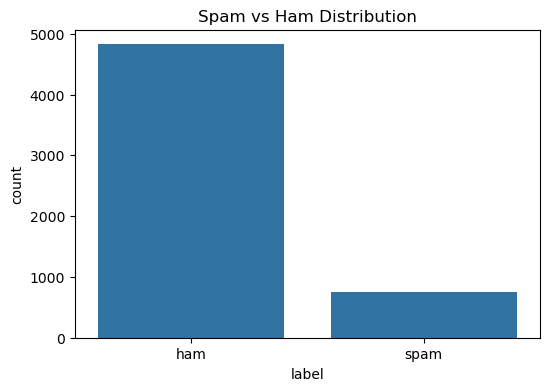

In [33]:
# Cell 10: Visualization

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='label')

plt.title("Spam vs Ham Distribution")

plt.show()

In [34]:
# TEXT PREPROCESSING

# Cell 11: Stopwords

stop_words = set(stopwords.words('english'))

print(list(stop_words)[:20])

['been', 'aren', 'don', 'once', 'their', "weren't", 'under', "she'd", 'too', 'ain', "don't", 'are', 'if', 'no', 'them', 'mightn', 'during', "it'd", 'my', "she'll"]


In [35]:
# Cell 12: Cleaning Function

def preprocess(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # tokenize
    words = text.split()

    # remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [36]:
# Cell 13: Apply Cleaning

df['clean_message'] = df['message'].apply(preprocess)

df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [37]:
# Cell 14: Encode Labels

df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [38]:
# TF-IDF FEATURE EXTRACTION

# Cell 15

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_message'])

y = df['label']

print(X.shape)

(5572, 5000)


In [39]:
# Cell 16: Train Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [41]:
# MODEL 1 - MULTINOMIAL NAIVE BAYES

# Cell 17

nb = MultinomialNB()

nb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [42]:
# Cell 18

pred_nb = nb.predict(X_test)

In [43]:
# Cell 19: Accuracy

accuracy_nb = accuracy_score(y_test, pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.9721973094170404


In [44]:
# Cell 20: Classification Report

print(classification_report(y_test, pred_nb))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



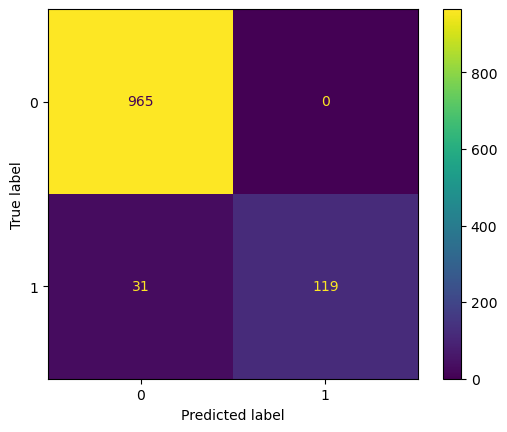

In [45]:
# Cell 21: Confusion Matrix

cm = confusion_matrix(y_test, pred_nb)

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [46]:
# MODEL 2 - LOGISTIC REGRESSION
# Cell 22

lr = LogisticRegression()

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
# Cell 23

pred_lr = lr.predict(X_test)

In [48]:
# Cell 24

accuracy_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9497757847533632


In [49]:
# Cell 25

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.96      0.65      0.78       150

    accuracy                           0.95      1115
   macro avg       0.95      0.82      0.87      1115
weighted avg       0.95      0.95      0.95      1115



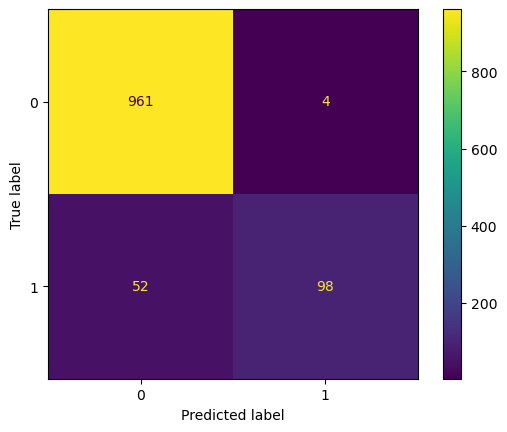

In [50]:
# Cell 26

cm = confusion_matrix(y_test, pred_lr)

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [51]:
# MODEL COMPARISON

# Cell 27

results = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy_nb,
        accuracy_lr
    ]

})

results

,Model,Accuracy
0,Naive Bayes,0.972197
1,Logistic Regression,0.949776


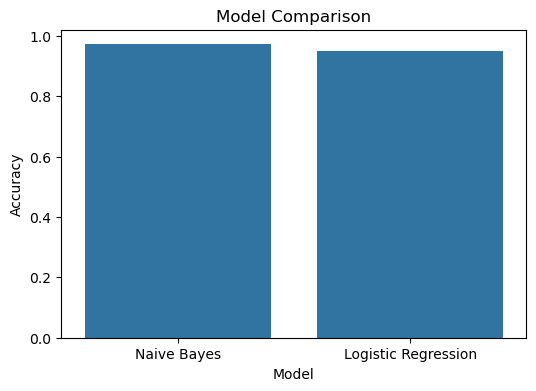

In [52]:
# Cell 28

plt.figure(figsize=(6,4))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Model Comparison")

plt.show()

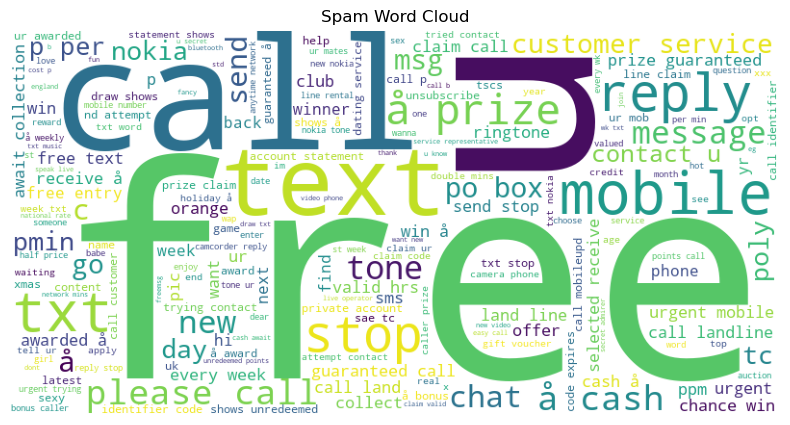

In [53]:
# WORD CLOUDS

# Cell 29: Spam WordCloud

spam_words = " ".join(
    df[df['label']==1]['clean_message']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Spam Word Cloud")

plt.show()

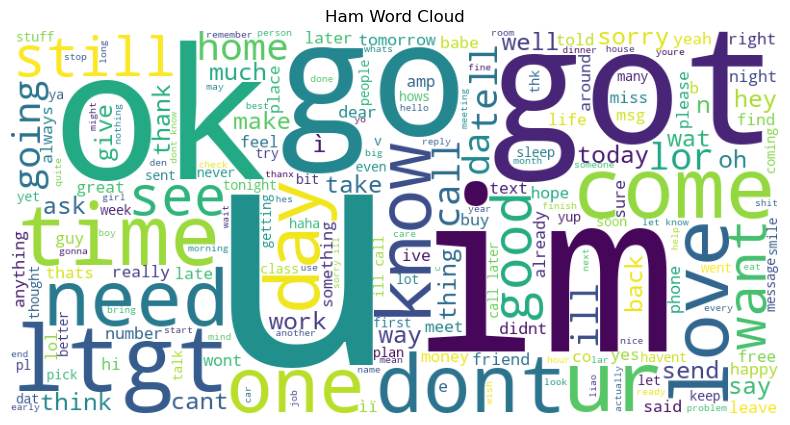

In [54]:
# Cell 30: Ham WordCloud

ham_words = " ".join(
    df[df['label']==0]['clean_message']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Ham Word Cloud")

plt.show()

In [55]:
# TEST CUSTOM EMAILS

# Cell 31

sample_messages = [

    "Congratulations! You have won a free iPhone.",

    "Let's meet tomorrow at 10 AM.",

    "Claim your reward now.",

    "Your Amazon order has been delivered."

]

In [56]:
# Cell 32

cleaned_messages = [

    preprocess(msg)

    for msg in sample_messages

]

sample_vector = tfidf.transform(cleaned_messages)

predictions = lr.predict(sample_vector)

In [57]:
# Cell 33

for msg, pred in zip(sample_messages, predictions):

    if pred == 1:
        print("SPAM :", msg)

    else:
        print("HAM  :", msg)

HAM  : Congratulations! You have won a free iPhone.
HAM  : Let's meet tomorrow at 10 AM.
SPAM : Claim your reward now.
HAM  : Your Amazon order has been delivered.


In [58]:
# PROJECT SUMMARY

# Cell 34

print("""
PROJECT COMPLETED

Steps Performed:

1. Loaded dataset
2. Explored data
3. Checked spam/ham distribution
4. Cleaned text
5. Removed stopwords
6. Converted text to TF-IDF
7. Trained Naive Bayes
8. Trained Logistic Regression
9. Evaluated models
10. Generated WordClouds
11. Tested custom messages

Email Spam Detection Successfully Implemented.
""")


PROJECT COMPLETED

Steps Performed:

1. Loaded dataset
2. Explored data
3. Checked spam/ham distribution
4. Cleaned text
5. Removed stopwords
6. Converted text to TF-IDF
7. Trained Naive Bayes
8. Trained Logistic Regression
9. Evaluated models
10. Generated WordClouds
11. Tested custom messages

Email Spam Detection Successfully Implemented.



In [59]:
# # Markdown Cell (TF-IDF Explanation)

# TF-IDF stands for Term Frequency - Inverse Document Frequency.

# TF measures how frequently a word appears in a document.

# IDF measures how unique a word is across all documents.

# Words that appear frequently in a document but rarely in the entire dataset receive higher TF-IDF scores.

# This helps machine learning models focus on important words and ignore common words.

In [60]:
# # Markdown Cell (Why Recall Matters)

# Recall is very important in spam detection because it measures how many actual spam messages are correctly identified.

# A low recall means many spam emails will enter the user's inbox.

# Spam emails may contain scams, phishing links, malware, or fraudulent offers.

# Therefore, maximizing recall helps improve security and reduces the chances of harmful emails reaching users.


In [62]:
# GitHub Description

# Email Spam Detection using NLP and Machine Learning. Implemented text preprocessing, TF-IDF vectorization, Multinomial Naive Bayes, Logistic Regression, performance evaluation, confusion matrix visualization, and WordCloud analysis using Python and Scikit-learn.

In [63]:
print("=" * 60)
print("🎉 TASK 4 COMPLETED SUCCESSFULLY! 🎉")
print("=" * 60)
print("📧 Project: Email Spam Detection using Machine Learning")
print("✅ Dataset Loaded")
print("✅ Data Preprocessing Completed")
print("✅ TF-IDF Feature Extraction Applied")
print("✅ Multinomial Naive Bayes Model Trained")
print("✅ Logistic Regression Model Trained")
print("✅ Models Evaluated")
print("✅ Confusion Matrix Generated")
print("✅ WordCloud Visualization Created")
print("✅ Custom Email Prediction Tested")
print("🏆 Email Spam Detection Project Completed Successfully!")
print("=" * 60)

🎉 TASK 4 COMPLETED SUCCESSFULLY! 🎉
📧 Project: Email Spam Detection using Machine Learning
✅ Dataset Loaded
✅ Data Preprocessing Completed
✅ TF-IDF Feature Extraction Applied
✅ Multinomial Naive Bayes Model Trained
✅ Logistic Regression Model Trained
✅ Models Evaluated
✅ Confusion Matrix Generated
✅ WordCloud Visualization Created
✅ Custom Email Prediction Tested
🏆 Email Spam Detection Project Completed Successfully!
